## Mécanique du vol, 2023-2024
#### Université Paul Sabatier, ENSEEIHT

Auteur: Christophe.Airiau@imft.fr

<table style="width: 100%">
    <colgroup>
       <col span="1" style="width: 40%;">
       <col span="1" style="width: 20%;">
       <col span="1" style="width: 45%;">
    </colgroup>
    <tbody>
        <tr>
            <td style="background-color: #ffffff"><img src="Images/fsi.png" width="200"></td>
            <td style="background-color: #ffffff"> </td>
            <td style="background-color: #ffffff"><img src="Images/N7.png" width="200"></td>
        </tr>
    </tbody>
</table>
 
 



# **<span style="color:orange">Vitesses optimales pour la finesse et la puissance, pour la polaire classique</span>**



# Introduction


Il existe deux vitesses importantes qu'on peut définir à partir d'une polaire:
* la vitesse $V_1$ qui maximise la finesse aérodynamique
* la vitesse $V_2$ qui minimise la puissance requise.

Dans la suite on va calculer ces vitesses et comparer toutes les quantités intéressantes de ces deux états particuliers.

On prend pour les indices:

* l'indice 1 pour les quantités du problème de la finesse;
* l'indice 2 pour le problème de la puissance. 
 
# **<span style="color:red">Objectifs</span>**

1. Déterminer les caractéristiques avions et aérodynamiques pour une configuration en finesse maximale 
2. Déterminer les caractéristiques avions et aérodynamiques pour une configuration de puissance requise minimale
3. Utiliser un module Python pour résoudre un problème d'ingénierie 
 


# **<span style="color:red">Définition de la polaire</span>**

La polaire classique est centrée autour de l'axe $C_L=0$:

<b>Polaire centrée</b>
$$
C_D = C_{D_0} + k~C_L^2,  \qquad \qquad k = \dfrac{1}{\pi~\lambda~e}
$$ 


Dans la suite on utilisera les quantités suivantes:

**Finesse aérodynamique**


<b></b>
    $$
    f =  \dfrac{C_L}{C_D} = \dfrac{C_L}{C_{D_0} + k~C_L^2}
    $$ 

            
**Pression dynamique**
            

<b> </b>
    $$
    q=  \dfrac 1 2 \rho~V^2
    $$ 
 

**Portance et traînée**
            

<b> </b>
    $$
    L = q~S~C_L = W, \qquad \qquad D = q~S~C_D 
    $$ 


**Puissance requise pour l'avancement**


<b>Puissance requise</b>
    $$
    Pr =  D \times V
    $$ 


<hr style="border:2px solid orange " width="99%">

# **<span style="color:red">I - Finesse optimale</span>**

<hr style="border:2px solid orange " width="99%">

La finesse optimale correspond à la maximisation de la finesse:


<b>Finesse optimale</b>
    $$
    f_{\max} = \max_{C_L} \dfrac{C_L}{C_{D_0} + k~C_L^2}
    $$ 


###  **<span style="color:magenta"> Calcul de la finesse optimale, des $C_l$, $C_d$, $D$ et $P_r$ correspondant </span>**

C'est en fait plus simple de **minimiser** son inverse:
$$
\dfrac 1  f_\max =\min_{C_L}  \dfrac{C_{D_0}} {C_L} + k~C_L
$$


## Démarche

1. On cherche $C_{L_1}$ tel que $\dfrac{dC_D}{dC_L}(C_{L_1}) = 0$
2. On trouve $C_{D_1}$ et $f_1=f_{\max} = \dfrac{C_{L_1}}{C_{D_1}}$
3. On calcule la vitesse correspondante: 

    <b>Définition de $V_1$</b>
    $$
    V_1 ^2  = \dfrac{2~W}{\rho~S~C_{L_1}}
    $$


4. On calcule $D_1$ et la puissance requise $P_{r_1}$:

    <b>Calcul de $P{r_1}$</b>
    $$
    Pr_1 = \dfrac{1}{2} \rho~S~C_{D_1}~V_1^3
    $$


In [1]:
# imports and local module 
from sympy.interactive import init_printing
import sympy.printing as printing
%matplotlib notebook
from sympy import Symbol, symbols, simplify, expand, integrate, diff, solveset, Abs, diff, collect, solve, pi
from sympy import latex, lambdify, sqrt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from IPython.display import display, Latex
init_printing()
style_list = mpl.style.available
print("Plot styles: ", style_list)
plt.style.use(style_list[11])  # choisir son style ...

Plot styles:  ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


Attention, le nom des variables dans le code peut légèrement différer de la version `Latex`

In [2]:
def print_(var, value):
    result = "$${} \qquad : \qquad {}$$".format(var, latex(value))
    display(Latex(result))

# déclaration des variables
C_D0, C_L, k, a = symbols("C_D0, C_L, k, a")
q, S, rho, V, rho_0 = symbols("q, S, rho, V, rho_0")
lambda_, e, f = symbols("lambda_, e, f")
k_value = symbols("k_value")
W, m, g, sigma = symbols("W, m , g, sigma")
k_value = 1 / (pi * lambda_ * e)
print_("k", k_value)

<IPython.core.display.Latex object>

Calcul de $\dfrac{df}{dC_L}$ puis le $C_L$ optimal $C_{L_{opt}}$ :  prendre la solution positive

In [3]:
C_D = C_D0 + k * C_L**2
f = C_L / C_D
inv_f = 1 / f
d_invf = simplify(inv_f.diff(C_L))
print_("\dfrac{d(1/f)}{dC_L}", d_invf)
s = solve(d_invf, C_L)
print_("Solution", s)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

On exprime le $C_{L_{opt}}$ en fonction de $\lambda$ et $e$

In [4]:
C_L_1 = s[1]
print_("C_{L_1}", C_L_1)
C_L_1.subs(k, k_value)

<IPython.core.display.Latex object>


<b>Calcul du $C{L_1}$</b>
$$
C_{L_1}  = \sqrt{\dfrac{C_{D_0}}{k}} = \sqrt{\pi~\lambda~e~C_{D_0}}
$$

Calcul du $C_{D_1}$ optimal, de la finesse maximale et de la traînée correspondante

In [5]:
q  = 1/2 * rho * V**2
C_D_1 = C_D.subs(C_L, C_L_1)
f_max = f.subs(C_L, C_L_1)
print_("C_D", C_D_1)
print_("f_{\max}", f_max)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<b>Calcul du $C_{D_1}$</b>
$$
C_{D_1}  =  2~C_{D_0}
$$

et

<b>Finesse maximale</b>
$$
f_\max  =  \dfrac{1}{2~\sqrt{k~C_{D_0}}} = \dfrac{1}{2} \sqrt{\dfrac{\pi~\lambda~e}{C_{D_0}}} 
$$

Au final on s'aperçoit que la polaire s'écrit sous la forme:


<b>Forme alternative de la polaire</b>
$$
C_D = C_{D_0}~\left[ 1 + \left(\dfrac{C_L}{C_{L_1}} \right)^2 \right]
$$



### Calcul de la vitesse 

In [6]:
sol = solve(W - q * S * C_L_1, V)
print_("solution", sol)
V_1 = sol[1]
print_("V_1", V_1)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>


<b>Calcul  de $V_1$</b>
$$
V_1^2 = \dfrac{2~W}{\rho~S~C_{L_1}}, \qquad \qquad V_1 = \sqrt{\dfrac{2~W}{\rho~S~\dfrac{C_{D_0}}{k}}}
$$ 

### Calcul de traînée

In [7]:
D_1 = q.subs(V, V_1) * S * C_D_1
print_("D_1       : ", D_1)

<IPython.core.display.Latex object>

### Calcul de puissance

In [8]:
Pr_1 = D_1 * V_1
print_("Pr_1", Pr_1)
print("sqrt(8) = ", np.sqrt(8))

<IPython.core.display.Latex object>

sqrt(8) =  2.8284271247461903


En utilisant que $ C_{D_1} = 2~C_{D_0}$ on trouve 

<div class="alert alert-block alert-success">
<b>Calcul  de $Pr_1$</b>
$$
Pr_1=  \rho~S~V_1~C_{D_0} \left( \dfrac{2~W}{\rho~S~C_{L_1}} \right)^{\frac 3 2} = 
\sqrt{\dfrac{8~W^3}{\rho~S}} \left( k^3~C_{D_0}\right)^{\frac 1 4}
$$ 
</div>

In [9]:
Pr_1b = sqrt(8 * W**3/(rho*S)) * (k**3*C_D0)**(1/4)
print_("Pr_1 (analytic)", Pr_1b)

<IPython.core.display.Latex object>

###  **<span style="color:magenta">Application numérique: calcul de la finesse optimale, des $C_L$, $C_D$, $D$ et $Pr$ correspondant </span>**
    
$\rho = 1.1$ kg/m$^3$,  $C_{d_0} = 0.013$, $e=0.85$, $\lambda=5$, $S=30$ m$^2$, $W = 5000 \times g$ N 

In [10]:
value = {rho: 1.1, C_D0: 0.013, e: 0.85, lambda_: 5, S:30, W: 5000 * 9.81}
value[k]=k_value.subs(value).evalf()
print_("k",  "%.4f" % value[k])
CL_1_num = C_L_1.subs(value).evalf()
print_("C_{L_1}", CL_1_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [11]:
print_("C_{D_1}", C_D_1.subs(value).evalf())
f_1 = f_max.subs(value).evalf()
print_("f_{\max}", f_1)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [12]:
np.sqrt(0.013/0.0749)

In [13]:
V_1_num = V_1.subs(value).evalf() * 3.6
print_("V_1 [km/h]", V_1_num)

<IPython.core.display.Latex object>

In [14]:
print_("D_1 [N]", D_1.subs(value).evalf())
Pr1_num = Pr_1.subs(value).evalf()
print_("Pr_1 [kW]", Pr1_num / 1000)
print_("Pr_1 [kW] (analytic)", Pr_1b.subs(value).evalf()/1000)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<hr style="border:2px solid orange " width="99%">

# **<span style="color:red">II - Optimisation de la puissance requise</span>**

<hr style="border:2px solid orange " width="99%">


D'abord on écrit la puissance requise sous la forme:

<b>Loi de puissance requise  $Pr$</b>
$$
Pr(V)=  \dfrac 1 2~\rho~S~C_D~V^3 = a_1~V^3 + \dfrac{a_2}{V} 
$$ 

## Méthode

1. Calculer $V_2$ telle que $\dfrac{dPr}{dV} = 0$
2. En déduire toutes les autres quantités $Pr_2$, $C_{L_2}$, $C_{D_2}$, $f_2$, $D_2$

In [15]:
# déclaration des variables additionnelles
a_1, a_2, Pr_ = symbols("a_1, a_2, Pr_")

### Loi de puissance

In [16]:
q = 1/2 * rho * V**2
C_L = W / (q * S)
C_D = C_D0 + k * C_L**2
D = q * S * C_D
L = q * S * C_L
Pr = D * V
print_("Pr", Pr.simplify())

<IPython.core.display.Latex object>

**Extraire les coefficients $a_1$ et $a_2$**

In [17]:
Pr2 = Pr.simplify()
a1 = Pr2.coeff(V, 3)
a2 = Pr2.coeff(V, -1)
print_("a_1", a1)
print_("a_2", a2)
print_("\\frac{a_2}{a_1}", a2/a1)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<b>Loi de puissance requise  $Pr$ (suite)</b>
$$
a_1 = \dfrac{\rho~S~C_{D_0}}{2}, \qquad \qquad 
a_2 = \dfrac{2~W^2~k}{\rho~S},\qquad \qquad
\dfrac{a_2}{a_1} = \dfrac{k}{ C_{D_0}}  \left(\dfrac{2~W}{\rho~S}\right)^2 =  
\left(\dfrac{2~W}{\rho~S~ C_{L_1}}\right)^2 
$$ 


### Calcul de la vitesse optimale $V_2$

In [18]:
def solve_min_Pr(P, V):
    sol = solve(P.diff(V), V)
    print_("Solution", sol)
    return sol
Pr_ = a_1 * V**3 + a_2 / V
sol1 = solve_min_Pr(Pr_, V)
sol2 = solve_min_Pr(Pr2, V)
V_2a = sol1[1]   # attention il faut vérifier, ce n'est pas toujours le même index
V_2b = sol2[3]   # attention il faut vérifier, ce n'est pas toujours le même index
print_("V_{2_a}", V_2a)
print_("V_{2_b}",  V_2b)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

La vitesse optimale vérifie:

<b>Vitesse optimale $V_2$</b>
$$
V_2^4 = \dfrac{1}{3} \dfrac{a_2}{a_1} =  \dfrac{4}{3} \dfrac{k}{C_{D_0}~(\rho~S)^2}~W^2 = 
\dfrac{4}{3}~\dfrac{W^2}{ (\rho~S~C_{L_{opt}})^2}
$$ 
 


<b>Rapport $V_2 / V_1$</b>
 $$
\dfrac{V_2}{V_1} = \dfrac{1}{3^{\frac 1 4}} \approx 0.76
$$
 
 


### Calcul de $C_{L_2}$ et  $C_{D_2}$

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

'f_2'

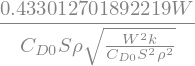

<IPython.core.display.Latex object>

In [19]:
C_L_2 = simplify(W / (q.subs(V, V_2a) * S))
print_("C_{L_2} = f(a_1, a_2)", C_L_2)
C_L_2_value = W / (q.subs(V, V_2b) * S)
print_("C_{L_2} value", C_L_2_value)
C_D_2_value = C_D.subs(V, V_2b)
print_("C{D_2} value", C_D_2_value)
C_D_2 = C_D.subs({C_L:C_L_2, V: V_2a})
print_("C_{D_2}", C_D_2)
f_2_value = C_L_2_value / C_D_2_value
display("f_2",f_2_value)
print_("\\frac{\\sqrt3}{4}",np.sqrt(3)/4)

----
On part de l'équation de la portance:

$$W = \dfrac{1}{2}~\rho~S~C_{L_2}~V_2^2 \qquad W^2 = \dfrac{1}{4} (\rho~S~C_{L_2})^2~V_2^4 
= \dfrac{1}{4}~(\rho~S~C_{L_2})^2~\dfrac{4}{3}~\dfrac{ W^2}{ (\rho~S~C_{L_1})^2}
$$
 
soit 
$$ 1 =   \dfrac{1}{3}~\dfrac{C_L^2 }{C_{L_{opt}}^2}, \qquad \qquad
$$


donc
$$
C_{D_2} =  C_{D_0} ~ \left[ 1 + \left(\dfrac{C_{L_2}}{C_{L_1}} \right)^2 \right] = 4~C_{D_0}
$$

<b>$C_L$ et $C_D$ du minimum de puissance</b>
 $$ C_{L_2} = \sqrt3 ~ C_{L_1}, \qquad \qquad  C_{D_2} = 2~C_{D_1}, \qquad 
 f_2 = \frac{\sqrt 3}{2}~f_1 =\frac{\sqrt 3}{4~\sqrt{k~C_{D_0}}} $$

### Calcul de $Pr_\min$

In [20]:
def calcul_puissance():
    leg = (" \\dfrac{1}{3^{\\frac 3 4}} + 3^{\\frac 1 4} ", "\\dfrac{4}{3^{\\frac 3 4}} 4^{\\frac 1 4}",
           "\\dfrac{4^{\\frac 5 4}}{3^{\\frac 3 4}} ")
    p = []
    p.append(pow(3, -3/4) + pow(3, 1/4))
    p.append(4/pow(3, 3/4)*pow(4, 1/4))
    p.append(pow(4, 5/4)/pow(3, 3/4))
    for l, v in zip(leg, p):
        print_(l, v)
calcul_puissance()

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [21]:
Pr_min=simplify(Pr_.subs(V, V_2a))
print_("Pr_{\min}", Pr_min)
Pr_min_b = simplify(Pr2.subs(V, V_2b))
print_("Pr_{\min} (value)", Pr_min_b)
print_("a_1 \\times a_2^3", a1*a2**3)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

----
**Calcul analytique**
$$
P_{r_\min} = \dfrac{1}{2}~\rho~S~V_2^2~C_{D_2} \times V_2 =
\dfrac{1}{2}\rho~S~\left(\dfrac{1}{3^{\frac 1 4}}~V_1\right)^2 ~(2~C_{D_1})~V_1~\dfrac{1}{3^{\frac 1 4}}
= \dfrac{1}{2}~\rho~S~V_1^3~C_{D_1} \times  \dfrac{2}{3^{\frac 3 4}}
=  \dfrac{2}{3^{\frac 3 4}}P_{r_1} \approx0.878~P_{r_1}
$$
on a aussi:

$$
P_{r_\min} = \left(a_1~a_2^3 \right)^{\frac 1 4}~\left(\dfrac{1}{3^{\frac 3 4}} + 3^{\frac 1 4} \right) 
= \dfrac{4}{3^{\frac 3 4}}~\left(a_1~a_2^3 \right)^{\frac 1 4} = \dfrac{4^{\frac 5 4}}{3^{\frac 3 4}}  \sqrt{\dfrac{W^3}{\rho~S}}~\left( k^3~C_{D_0}\right)^{\frac 1 4}
$$

Pour obtenir la puissance minimale on a augmenté la traînée mais on a diminué la vitesse.

In [22]:
print_("Pr_{\\min} / Pr_1", 2 /pow(3, 3/4))

<IPython.core.display.Latex object>

###  **<span style="color:magenta"> Application numérique: calcul de la finesse optimale, le $C_L$, $C_D$, $D$ et $Pr$ correspondant </span>**


In [23]:
V_2_num =  V_2b.subs(value).evalf()*3.6
print_("V_2", V_2_num)
print_("\\frac{V_2}{V_1}", V_2_num/V_1_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [24]:
CL_2_num = C_L_2_value.subs(value).evalf()
print_("C_{L_2}", CL_2_num)
print_("\\frac{C_{L_2}}{C_{L_1}}", CL_2_num / CL_1_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [25]:
CD_2_num = C_D_2_value.subs(value).evalf()
print_("C_{D_2}", CD_2_num)  
f_2_num = CL_2_num / CD_2_num
print_("f_2", f_2_num)
print_("\\frac{f_2}{f_1}", f_2_num / f_1)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [26]:
Pr_min_num = Pr_min_b.subs(value).evalf()
print_("Pr_{\\min} [kW]", Pr_min_num/1000)
print_("\\frac {Pr_2}{Pr_1}", Pr_min_num/Pr1_num)

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<hr style="border:2px solid orange " width="99%">

# **<span style="color:red">III - Approche "Design"</span>**

<hr style="border:2px solid orange " width="99%">

1. Conception directe:

    * Entrées:
    $$
    h, W, W/S, \lambda, e, C_{D_0}
    $$

    * Sorties:
    $$
    S, b, \rho, k , C_{L_i}, C_{D_i}, f_i, V_i, D_i, Pr_i 
    $$

2. Conception inverse:

    * Entrées:
    $$
    e, h, C_{L_1}, f_1, V_1, Pr_1 
    $$
    
    * Sorties:
    $$
    \rho, k, C_{D_0}, \lambda, S, b,   W, W/S,  C_{L_2}, f_2, V_2, Pr_2 
    $$